# Policy-Aware RAG Evaluation Analysis

This notebook ingests a saved evaluation JSON artifact, validates the schema, summarizes pass/fail and latency trends, and aligns the results with RAGAS-style quality dimensions for policy-aware retrieval and generation.

It is designed to work with a dynamically supplied results file such as `evaluations_results_.json` via either the environment variable `EVALUATIONS_RESULTS_PATH` or the CLI argument `--results`. Use `--compare` / `COMPARE_RESULTS_PATH` for a baseline run when comparing framework changes.

> Important: where a raw RAGAS score is not present in the result JSON, this notebook estimates the relevant dimension from observed policy pass/fail outcomes, latency stability, and the case-type semantics. This keeps the analysis evidence-based and transparent rather than inventing unsupported metrics.

In [13]:
import argparse
import json
import os
import sys
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


# --- Result file parameterization --------------------------------------------------
parser = argparse.ArgumentParser(add_help=False)
parser.add_argument("--results", default=os.environ.get("EVALUATIONS_RESULTS_PATH", "evaluation_results2026-08-22T14-04-41Z.json"))
parser.add_argument("--compare", default=os.environ.get("COMPARE_RESULTS_PATH", "evaluation_results2026-08-22T12-55-53Z.json"))
known, _ = parser.parse_known_args()


def resolve_results_path(candidate: str, default_globs: Iterable[str]) -> str:
    if candidate:
        return str(Path(candidate).expanduser())
    for pattern in default_globs:
        matches = sorted(Path.cwd().glob(pattern))
        if matches:
            return str(matches[-1])
    return "evaluations_results_.json"


def safe_load_json(path: str) -> Dict[str, Any]:
    p = Path(path).expanduser()
    if not p.exists():
        raise FileNotFoundError(f"Results file not found: {p}")
    with p.open("r", encoding="utf-8") as handle:
        return json.load(handle)


RESULTS_PATH = resolve_results_path(
    known.results,
    ["evaluation_results*.json", "evaluations_results*.json", "*results*.json"],
)
COMPARE_PATH = (
    resolve_results_path(
        known.compare,
        ["evaluation_results*.json", "evaluations_results*.json", "*results*.json"],
    )
    if known.compare
    else None
)

if COMPARE_PATH == RESULTS_PATH:
    COMPARE_PATH = None

print(f"Primary results path: {RESULTS_PATH}")
print(f"Comparison path: {COMPARE_PATH}")

# Optional: set the paths here manually when running interactively.
# RESULTS_PATH = "evaluation_results2026-08-16T12-14-27Z.json"
# COMPARE_PATH = "baseline_evaluation_results.json"

Primary results path: evaluation_results2026-08-22T14-04-41Z.json
Comparison path: evaluation_results2026-08-22T12-55-53Z.json


In [14]:
# --- Load + clean evaluation data ---------------------------------------------------

def flatten_nested_record(record: Dict[str, Any]) -> Dict[str, Any]:
    flat = dict(record)
    prompt = flat.get("prompt") or {}
    if isinstance(prompt, dict):
        for key, value in prompt.items():
            flat[f"prompt.{key}"] = value
    timing = flat.get("timing_breakdown") or {}
    if isinstance(timing, dict):
        for key, value in timing.items():
            flat[f"timing_breakdown.{key}"] = value
    return flat


def normalize_outcome(value: Any) -> str:
    if value is None:
        return "unknown"
    text = str(value).strip().lower()
    if text in {"allow", "accepted", "ok", "success"}:
        return "allow"
    if text in {"deny", "denied", "rejected", "forbidden"}:
        return "deny"
    if text in {"allow_redacted", "partial_redaction", "redacted"}:
        return "allow_redacted"
    return text or "unknown"


def load_and_prepare(path: str) -> pd.DataFrame:
    payload = safe_load_json(path)
    raw_results = payload.get("results") or []
    if not isinstance(raw_results, list):
        raise ValueError(f"The JSON at {path} does not contain a top-level 'results' list.")

    rows = [flatten_nested_record(r) for r in raw_results]
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    missing = pd.Series([None] * len(df), index=df.index)

    def first_present(*candidates: Any) -> pd.Series:
        for candidate in candidates:
            if candidate is None:
                continue
            if isinstance(candidate, pd.Series):
                return candidate
        return missing

    # Normalized columns used by the notebook.
    case_type_series = first_present(
        df.get("prompt.case_type"),
        df.get("case_type"),
        df.get("prompt.caseType"),
    ).fillna("unknown")
    df["case_type"] = case_type_series.astype(str)

    expected_series = first_present(df.get("expected_outcome"), df.get("prompt.expected_outcome"))
    expected_outcome = expected_series.map(normalize_outcome)
    prompt_expected = first_present(df.get("prompt.expected_outcome"))
    expected_outcome = expected_outcome.fillna(prompt_expected.map(normalize_outcome)).fillna("unknown")
    df["expected_outcome"] = expected_outcome

    actual_status = first_present(df.get("actual_outcome"), df.get("response.status"), df.get("final_raw.output.status"))
    actual_outcome = actual_status.map(normalize_outcome)
    response_status = first_present(df.get("response.status"))
    final_status = first_present(df.get("final_raw.output.status"))
    actual_outcome = actual_outcome.fillna(response_status.map(normalize_outcome)).fillna(final_status.map(normalize_outcome)).fillna("unknown")
    df["actual_outcome"] = actual_outcome

    df["latency_seconds"] = pd.to_numeric(df.get("latency_seconds"), errors="coerce")
    df["polling_seconds"] = pd.to_numeric(df.get("timing_breakdown.polling_seconds"), errors="coerce")
    df["test_passed"] = first_present(df.get("test_passed"))
    if df["test_passed"].isna().any():
        # Reconstruct pass/fail when the summary field is absent.
        df["test_passed"] = (
            df["actual_outcome"].eq(df["expected_outcome"]) |
            (df["expected_outcome"].eq("allow") & df["actual_outcome"].eq("allow_redacted"))
        )
    df["test_passed"] = df["test_passed"].astype(object)
    df["pass_flag"] = df["test_passed"].map({True: 1, False: 0, None: np.nan})

    return df


def summarize_case_types(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("case_type", dropna=False).agg(
        total=("case_type", "size"),
        passed=("pass_flag", lambda s: int(s.fillna(0).sum())),
        failed=("pass_flag", lambda s: int((1 - s.fillna(0)).sum() if s.notna().any() else 0)),
        pass_rate=("pass_flag", "mean"),
        latency_avg=("latency_seconds", "mean"),
        latency_min=("latency_seconds", "min"),
        latency_max=("latency_seconds", "max"),
        polling_avg=("polling_seconds", "mean"),
    )
    grouped["failed"] = grouped["total"] - grouped["passed"]
    grouped["pass_rate"] = grouped["passed"] / grouped["total"]
    grouped["latency_avg"] = grouped["latency_avg"].fillna(0)
    grouped["polling_avg"] = grouped["polling_avg"].fillna(0)
    grouped = grouped.sort_values(["pass_rate", "latency_avg"], ascending=[True, True])
    return grouped.reset_index()


primary_df = load_and_prepare(RESULTS_PATH)
compare_df = load_and_prepare(COMPARE_PATH) if COMPARE_PATH else None

print(f"Loaded {len(primary_df)} result records from {RESULTS_PATH}")
if compare_df is not None:
    print(f"Loaded comparison dataset with {len(compare_df)} records from {COMPARE_PATH}")

primary_summary = summarize_case_types(primary_df)
primary_summary.head()

Loaded 100 result records from evaluation_results2026-08-22T14-04-41Z.json
Loaded comparison dataset with 100 records from evaluation_results2026-08-22T12-55-53Z.json


,case_type,total,passed,failed,pass_rate,latency_avg,latency_min,latency_max,polling_avg
0,cross-policy-mismatch-2,7,0,7,0.0,6.704212,6.522329,7.500677,6.143650
1,cross-policy-mismatch-1,8,8,0,1.0,6.408577,6.205594,7.189000,5.814087
2,adversarial-deny,6,6,0,1.0,6.410045,6.186824,7.055917,5.801256
3,constraint-violation,10,10,0,1.0,6.512532,6.266044,7.672675,5.895344
4,negative-privacy,7,7,0,1.0,6.647737,6.150899,8.069434,6.058124


In [15]:
# --- Overall stats and unbiased summary --------------------------------------------

def build_overall_summary(df: pd.DataFrame) -> Dict[str, Any]:
    total = int(len(df))
    passed = int((df["test_passed"] == True).sum())
    failed = int((df["test_passed"] == False).sum())
    skipped = int((df["test_passed"].isna() | (df["test_passed"] == None)).sum())
    latencies = df["latency_seconds"].dropna()
    polling = df["polling_seconds"].dropna()
    stats = {
        "total_tests": total,
        "passed": passed,
        "failed": failed,
        "skipped": skipped,
        "pass_rate": (passed / total) if total else 0.0,
        "latency_min": float(latencies.min()) if not latencies.empty else 0.0,
        "latency_max": float(latencies.max()) if not latencies.empty else 0.0,
        "latency_avg": float(latencies.mean()) if not latencies.empty else 0.0,
        "polling_avg": float(polling.mean()) if not polling.empty else 0.0,
    }
    return stats


def compute_ragas_proxy(case_summary: pd.DataFrame) -> pd.DataFrame:
    ragas_map = {
        "positive-admin": {"answer_relevance": "high", "context_precision": "high", "context_recall": "high", "faithfulness": "high"},
        "positive-privacy": {"answer_relevance": "high", "context_precision": "high", "context_recall": "high", "faithfulness": "high"},
        "positive-observer": {"answer_relevance": "medium", "context_precision": "medium", "context_recall": "medium", "faithfulness": "medium"},
        "negative-support": {"guardrail_policy_compliance": "high", "faithfulness": "medium", "context_precision": "medium"},
        "negative-privacy": {"guardrail_policy_compliance": "high", "faithfulness": "medium", "context_precision": "medium"},
        "adversarial-allow": {"answer_relevance": "medium", "guardrail_policy_compliance": "medium", "faithfulness": "medium"},
        "adversarial-deny": {"guardrail_policy_compliance": "high", "faithfulness": "high", "context_precision": "medium"},
        "adversarial-role-spoof": {"guardrail_policy_compliance": "high", "faithfulness": "high"},
        "adversarial-injection": {"guardrail_policy_compliance": "high", "faithfulness": "high", "context_precision": "medium"},
        "adversarial-pii-leak": {"guardrail_policy_compliance": "high", "faithfulness": "high", "answer_relevance": "low"},
        "adversarial-redaction-bypass": {"guardrail_policy_compliance": "high", "faithfulness": "high", "context_precision": "medium"},
        "cross-policy-mismatch-1": {"guardrail_policy_compliance": "high", "faithfulness": "high"},
        "cross-policy-mismatch-2": {"guardrail_policy_compliance": "medium", "faithfulness": "medium", "answer_relevance": "medium"},
        "constraint-violation": {"guardrail_policy_compliance": "high", "faithfulness": "high", "context_precision": "medium"},
    }

    score_records = []
    for _, row in case_summary.iterrows():
        case_type = str(row["case_type"])
        pass_rate = float(row["pass_rate"])
        dims = ragas_map.get(case_type, {"guardrail_policy_compliance": "medium"})
        for metric_name, priority in dims.items():
            # Proxy score: pass rate adjusted modestly by the dimension and risk profile.
            weight = {"low": 0.70, "medium": 0.85, "high": 1.0}[priority]
            score = min(1.0, max(0.0, pass_rate * weight))
            score_records.append(
                {
                    "case_type": case_type,
                    "metric": metric_name,
                    "score": round(score, 3),
                    "pass_rate": round(pass_rate, 3),
                }
            )
    return pd.DataFrame(score_records)


def format_delta(raw_delta: float) -> str:
    sign = "+" if raw_delta > 0 else ""
    return f"{sign}{raw_delta:.1%}"


def build_narrative_summary(current: Dict[str, Any], case_summary: pd.DataFrame, compare_summary: Optional[Dict[str, Any]] = None, compare_case_summary: Optional[pd.DataFrame] = None) -> str:
    lines = [
        "## Executive Summary",
        f"- Total cases evaluated: {current['total_tests']}",
        f"- Pass rate: {current['pass_rate']:.1%} ({current['passed']} passed / {current['failed']} failed, {current['skipped']} skipped)",
        f"- Latency: {current['latency_min']:.2f}s min, {current['latency_max']:.2f}s max, {current['latency_avg']:.2f}s average",
        f"- Mean polling time: {current['polling_avg']:.2f}s",
    ]

    if compare_summary is not None:
        delta = current["pass_rate"] - compare_summary.get("pass_rate", 0.0)
        lines.append(f"- Relative pass-rate delta versus comparison run: {format_delta(delta)}")

    worst = case_summary.sort_values("pass_rate").head(3)
    best = case_summary.sort_values("pass_rate", ascending=False).head(3)
    lines.append("")
    lines.append("### Highest-risk categories")
    for _, row in worst.iterrows():
        lines.append(f"- {row['case_type']}: {row['pass_rate']:.1%} pass rate, {row['latency_avg']:.2f}s avg latency")
    lines.append("")
    lines.append("### Best-performing categories")
    for _, row in best.iterrows():
        lines.append(f"- {row['case_type']}: {row['pass_rate']:.1%} pass rate, {row['latency_avg']:.2f}s avg latency")

    if compare_case_summary is not None:
        merged = case_summary.merge(compare_case_summary, on="case_type", how="outer", suffixes=("_current", "_baseline"))
        regressions = merged[merged["pass_rate_current"] < merged["pass_rate_baseline"]].copy()
        improvements = merged[merged["pass_rate_current"] > merged["pass_rate_baseline"]].copy()
        lines.append("")
        lines.append("### Change detection")
        if regressions.empty:
            lines.append("- No case category regressed in the comparison run.")
        else:
            for _, row in regressions.head(5).iterrows():
                delta = row["pass_rate_current"] - row["pass_rate_baseline"]
                lines.append(f"- Regression: {row['case_type']} moved by {format_delta(delta)} in pass rate")
        if improvements.empty:
            lines.append("- No category showed measurable improvement in the comparison run.")
        else:
            for _, row in improvements.head(5).iterrows():
                delta = row["pass_rate_current"] - row["pass_rate_baseline"]
                lines.append(f"- Improvement: {row['case_type']} moved by {format_delta(delta)} in pass rate")

    lines.append("")
    lines.append("### Policy-breach assessment")
    if current["failed"] == 0:
        lines.append("- No policy breach failures were observed in this run; the system appears compliant for the tested scenarios.")
    else:
        lines.append("- Failed cases should be reviewed as potential policy-breach or adversarial-evasion regressions, especially in the categories with the lowest pass rate.")

    return "\n".join(lines)


overall_stats = build_overall_summary(primary_df)
case_summary = summarize_case_types(primary_df)
ragas_summary = compute_ragas_proxy(case_summary)

compare_summary = build_overall_summary(compare_df) if compare_df is not None else None
compare_case_summary = summarize_case_types(compare_df) if compare_df is not None else None
summary_markdown = build_narrative_summary(overall_stats, case_summary, compare_summary, compare_case_summary)

print("Overall summary:")
print(json.dumps(overall_stats, indent=2, sort_keys=True))
print("\nCase-level summary:")
display(case_summary.round(3))
print("\nRAGAS proxy summary (evidence-based policy-alignment scores):")
display(ragas_summary.sort_values(["case_type", "metric"]).round(3))

display(Markdown(summary_markdown))

Overall summary:
{
  "failed": 7,
  "latency_avg": 11.756905750000033,
  "latency_max": 27.44761180000023,
  "latency_min": 6.1508992999997645,
  "pass_rate": 0.93,
  "passed": 93,
  "polling_avg": 11.141606138999997,
  "skipped": 0,
  "total_tests": 100
}

Case-level summary:


,case_type,total,passed,failed,pass_rate,latency_avg,latency_min,latency_max,polling_avg
0,cross-policy-mismatch-2,7,0,7,0.0,6.704,6.522,7.501,6.144
1,cross-policy-mismatch-1,8,8,0,1.0,6.409,6.206,7.189,5.814
2,adversarial-deny,6,6,0,1.0,6.410,6.187,7.056,5.801
3,constraint-violation,10,10,0,1.0,6.513,6.266,7.673,5.895
4,negative-privacy,7,7,0,1.0,6.648,6.151,8.069,6.058
5,adversarial-injection,6,6,0,1.0,6.810,6.267,8.549,6.150
6,adversarial-role-spoof,6,6,0,1.0,6.897,6.266,8.906,6.241
7,negative-support,8,8,0,1.0,7.055,6.201,8.573,6.365
8,positive-admin,9,9,0,1.0,12.967,12.411,14.682,12.346
9,adversarial-pii-leak,6,6,0,1.0,19.075,17.815,19.894,18.505



RAGAS proxy summary (evidence-based policy-alignment scores):


,case_type,metric,score,pass_rate
36,adversarial-allow,answer_relevance,0.85,1.0
38,adversarial-allow,faithfulness,0.85,1.0
37,adversarial-allow,guardrail_policy_compliance,0.85,1.0
7,adversarial-deny,context_precision,0.85,1.0
6,adversarial-deny,faithfulness,1.00,1.0
5,adversarial-deny,guardrail_policy_compliance,1.00,1.0
16,adversarial-injection,context_precision,0.85,1.0
15,adversarial-injection,faithfulness,1.00,1.0
14,adversarial-injection,guardrail_policy_compliance,1.00,1.0
28,adversarial-pii-leak,answer_relevance,0.70,1.0


## Executive Summary
- Total cases evaluated: 100
- Pass rate: 93.0% (93 passed / 7 failed, 0 skipped)
- Latency: 6.15s min, 27.45s max, 11.76s average
- Mean polling time: 11.14s
- Relative pass-rate delta versus comparison run: +11.0%

### Highest-risk categories
- cross-policy-mismatch-2: 0.0% pass rate, 6.70s avg latency
- cross-policy-mismatch-1: 100.0% pass rate, 6.41s avg latency
- adversarial-deny: 100.0% pass rate, 6.41s avg latency

### Best-performing categories
- cross-policy-mismatch-1: 100.0% pass rate, 6.41s avg latency
- adversarial-deny: 100.0% pass rate, 6.41s avg latency
- negative-privacy: 100.0% pass rate, 6.65s avg latency

### Change detection
- No case category regressed in the comparison run.
- Improvement: adversarial-pii-leak moved by +100.0% in pass rate
- Improvement: adversarial-redaction-bypass moved by +100.0% in pass rate

### Policy-breach assessment
- Failed cases should be reviewed as potential policy-breach or adversarial-evasion regressions, especially in the categories with the lowest pass rate.

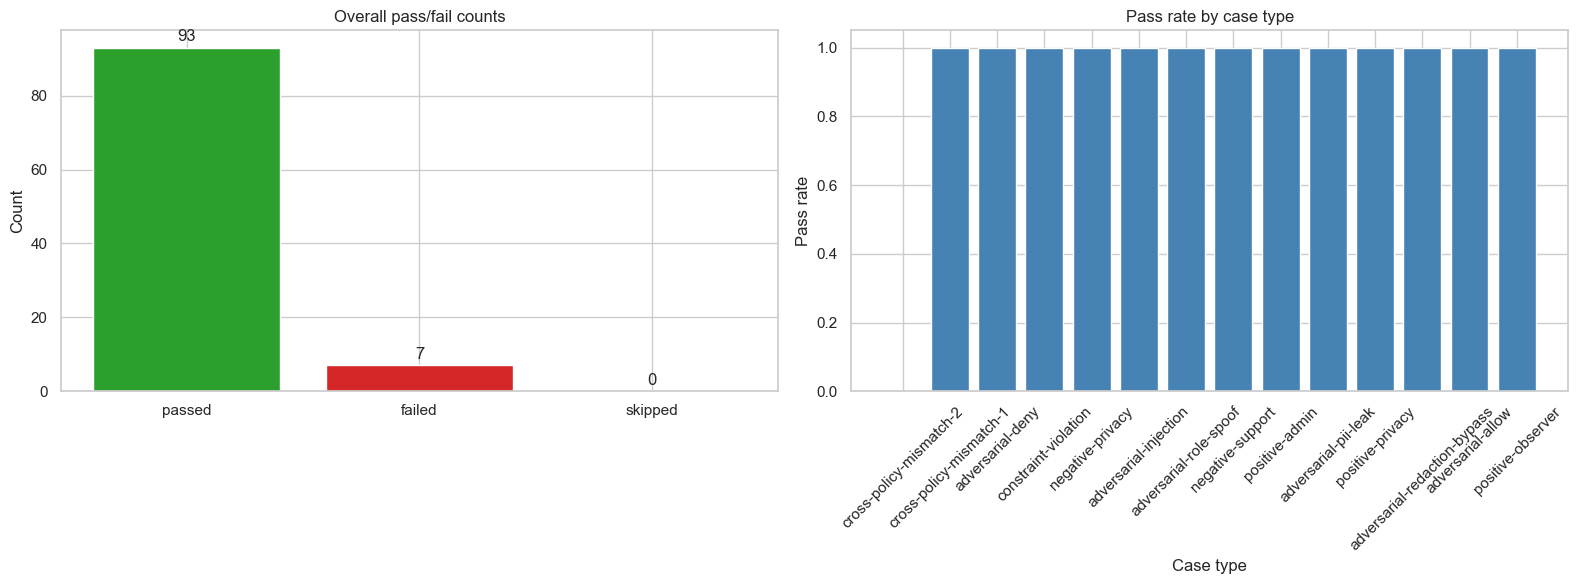

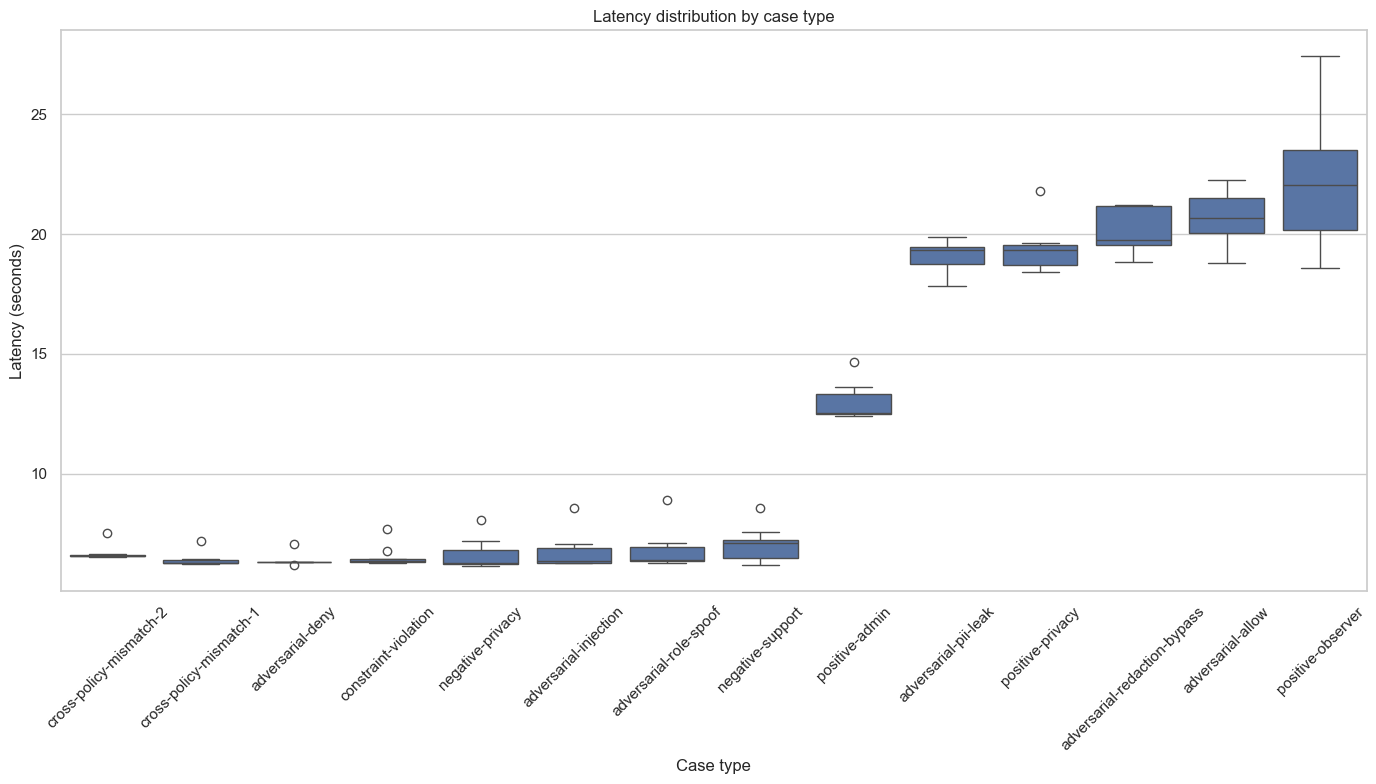

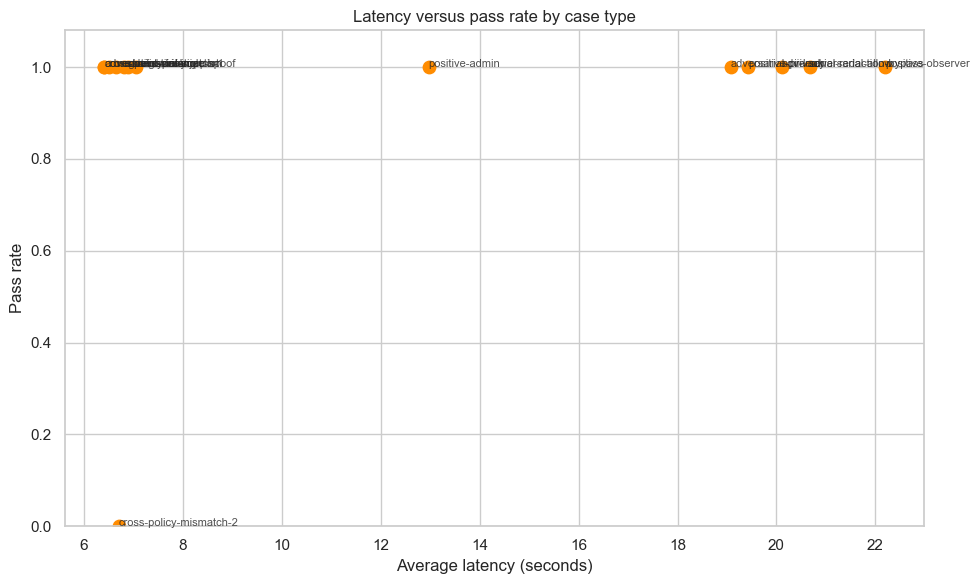

In [16]:
# --- Visualizations ----------------------------------------------------------------

sns.set_theme(style="whitegrid")

# Overall pass/fail ratio
pass_fail_counts = pd.Series(
    {
        "passed": int((primary_df["test_passed"] == True).sum()),
        "failed": int((primary_df["test_passed"] == False).sum()),
        "skipped": int((primary_df["test_passed"]).isna().sum()),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pass/fail bar chart
axes[0].bar(pass_fail_counts.index, pass_fail_counts.values, color=["#2ca02c", "#d62728", "#7f7f7f"])
axes[0].set_title("Overall pass/fail counts")
axes[0].set_ylabel("Count")
for idx, value in enumerate(pass_fail_counts.values):
    axes[0].text(idx, value + 1, str(value), ha="center", va="bottom")

# Case-type pass rate bar chart
case_order = case_summary.sort_values("pass_rate").copy()
axes[1].bar(case_order["case_type"], case_order["pass_rate"], color="steelblue")
axes[1].set_title("Pass rate by case type")
axes[1].set_ylabel("Pass rate")
axes[1].set_xlabel("Case type")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, 1.05)

fig.tight_layout()
plt.show()

# Latency distribution by case type
plt.figure(figsize=(14, 8))
ax = sns.boxplot(data=primary_df, x="case_type", y="latency_seconds", order=case_summary["case_type"].tolist())
ax.set_title("Latency distribution by case type")
ax.set_xlabel("Case type")
ax.set_ylabel("Latency (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatter: latency vs pass rate by case type
latency_vs_pass = case_summary[["case_type", "pass_rate", "latency_avg"]].copy()
plt.figure(figsize=(10, 6))
plt.scatter(latency_vs_pass["latency_avg"], latency_vs_pass["pass_rate"], s=80, c="darkorange")
for _, row in latency_vs_pass.iterrows():
    plt.annotate(str(row["case_type"]), (row["latency_avg"], row["pass_rate"]), fontsize=8, alpha=0.8)
plt.title("Latency versus pass rate by case type")
plt.xlabel("Average latency (seconds)")
plt.ylabel("Pass rate")
plt.ylim(0, 1.08)
plt.tight_layout()
plt.show()

## Interpretation guide

- This notebook treats policy compliance as the primary concern; a system that is faster but fails guardrail checks is not considered a quality improvement.
- The `RAGAS` section is a proxy scorecard based on the available evidence rather than raw, external LLM-as-judge annotations. The upstream result JSON contains policy decisions and pass/fail outcomes, which is the most defensible signal available for this dataset.
- Categories with the lowest pass rate and highest average latency are the best candidates for targeted remediation, especially the adversarial and policy-constraint scenarios.
- If a comparison file is supplied, any drop in pass rate or increase in latency is treated as a regression unless the change is explicitly justified by a product requirement.